# **Encroaching Fine Dining: A Statistical Analysis of the Best Areas to Find Safe Food in Austin**
I310D Final Project Spring 2025

Group Members (girl idk lol!): Krishna Pillai, Chloe Low, Siri Bandreddy

Professor: Abhijit Mishra

## Project Description

This project aims to find areas and zip codes within Austin that have the cleanest food establishments available. The dataset that we are using is provided from the Austin City government, at data.AustinTexas.gov ([Food Establishment Inspection Scores](https://data.austintexas.gov/Health-and-Community-Services/Food-Establishment-Inspection-Scores/ecmv-9xxi/data_preview)).

Doing this analysis of food establishment inspection scores is important for populations of people that may have certain attributes—like gluten free, food allergic, immunocompromised—find restaurants that they can be assured will fit their needs better. Additionally, it'll give many people assurance and confidence that the food they're consuming has been handled properly and hasn't been tampered with.

Rename csv as Food_Establishment_Inspection_Scores_Austin

# **Loading Dataset into a Dataframe and Cleaning**

In [ ]:
#import pandas to create dataframe
import pandas as pd

#read dataset and then create pandas dataframe
food_df = pd.read_csv("Food_Establishment_Inspection_Scores_Austin.csv")
#display first 5 rows of changed dataframe
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23225 entries, 0 to 23224
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Restaurant Name      23225 non-null  object 
 1   Zip Code             23208 non-null  float64
 2   Inspection Date      23225 non-null  object 
 3   Score                23225 non-null  int64  
 4   Address              23214 non-null  object 
 5   Facility ID          23225 non-null  int64  
 6   Process Description  23225 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.2+ MB


Load in the dataset in a csv form, and

In [ ]:
#remove unnecessary columns like address and facility ID
food_df = food_df.drop("Process Description", axis = 1)
#clean up all null entries in the dataset
food_df = food_df.dropna(subset='Zip Code')
display(food_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 23208 entries, 0 to 23224
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant Name  23208 non-null  object 
 1   Zip Code         23208 non-null  float64
 2   Inspection Date  23208 non-null  object 
 3   Score            23208 non-null  int64  
 4   Address          23208 non-null  object 
 5   Facility ID      23208 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 1.2+ MB


None

In [ ]:
#turning inspection date column dtype from object to a datetime object
food_df["Inspection Date"] = pd.to_datetime(food_df["Inspection Date"], format="%m/%d/%Y")
#turn zip code from a float64 object to an int
food_df['Zip Code'] = food_df['Zip Code'].astype(int)
cleaned_food_df = food_df
#keep only inspections from the past year
cleaned_food_df = cleaned_food_df[cleaned_food_df['Inspection Date'].dt.year >= 2024]
cleaned_food_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6318 entries, 7 to 23218
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Restaurant Name  6318 non-null   object        
 1   Zip Code         6318 non-null   int64         
 2   Inspection Date  6318 non-null   datetime64[ns]
 3   Score            6318 non-null   int64         
 4   Address          6318 non-null   object        
 5   Facility ID      6318 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 345.5+ KB


In [ ]:
import numpy as np
#to make sure it's reproducible, pick a random seed number
np.random.seed(45)
#use sample to randomly pick 500 entries from the dataframe
new_food_df = cleaned_food_df.sample(n=550, replace=False)
new_food_df.head()

,Restaurant Name,Zip Code,Inspection Date,Score,Address,Facility ID
13560,Jason's Deli,78748,2024-10-28,96,"9600 S IH\nAUSTIN, TX 78748",10017881
15139,MN - Dollar General #6946,78653,2024-10-08,93,"12750 LAPOYNOR ST\nMANOR, TX 78653\n(30.33562,...",2804037
8695,Headliners,78701,2024-01-23,86,"221 W 6TH ST\nAUSTIN, TX 78701\n(30.26857, -97...",2800399
787,Kung Fu Tea,78757,2024-10-10,78,"9070 RESEARCH BLVD\nAUSTIN, TX 78757\n(30.3727...",12398512
6023,LW - Santa Catarina,78734,2024-01-24,81,"1310 S FM 620 RD\nLAKEWAY, TX 78734\n(30.34988...",11175645


In [ ]:
#Create csv with randomly selected restaurants
new_food_df.to_csv("New_Inspection_Scores_2024_Austin.csv")

Now, with this csv, we have to create two new columns-Google Ratings and Yelp Ratings, and manually input each rating for each restaurant, removing rows that have no Yelp/Google rating. With this, we have a new dataset to analyze.

[Establishments with Ratings](https://docs.google.com/spreadsheets/d/1goQKxZt-G3XxEUBbtKVZ_FDMavM0zirU-3REqu8P7BI/edit?usp=sharing)

In [ ]:
#Create a new dataframe to analyze using the file with all of the ratings
ratings_df = pd.read_csv("Establishments_With_Ratings.csv")
ratings_df = ratings_df.drop("Facility ID", axis = 1)

#removing the /n and the coordinates from the addresses for easy access later
def clearn_string_and_convert(s):
    s = s.replace("\n"," ")
    if '(' in s and ')' in s:
      s = s[:s.index('(')]
    converted = s
    return converted

#apply removing /n and coordinates onto address
ratings_df["Address"] = ratings_df["Address"].apply(clearn_string_and_convert)

ratings_df.head()

,Unnamed: 0,Restaurant Name,Zip Code,Inspection Date,Score,Address,Google Rating,Yelp Rating
0,13560,Jason's Deli,78748,2024-10-28,96,"9600 S IH AUSTIN, TX 78748",4.4,3.7
1,15139,MN - Dollar General #6946,78653,2024-10-08,93,"12750 LAPOYNOR ST MANOR, TX 78653",3.9,1.5
2,8695,Headliners,78701,2024-01-23,86,"221 W 6TH ST AUSTIN, TX 78701",4.7,4.7
3,787,Kung Fu Tea,78757,2024-10-10,78,"9070 RESEARCH BLVD AUSTIN, TX 78757",4.4,4.3
4,6023,LW - Santa Catarina,78734,2024-01-24,81,"1310 S FM 620 RD LAKEWAY, TX 78734",4.5,4.4


In [ ]:
#turning inspection date column dtype from object to a datetime object
ratings_df["Inspection Date"] = pd.to_datetime(food_df["Inspection Date"], format="%m/%d/%Y")

# **Clustering**

In [ ]:
from sklearn.cluster import KMeans

#Select the features we need for clustering
rating_groups = ratings_df[["Score", "Google Rating", "Yelp Rating"]]

#After playing around with various clusters, select 3 for cluster value
kmeans_model = KMeans(n_clusters=5, random_state=0, n_init=1)
#use kmean_model.fit_predict() to get labels on cluster groups
ratings_df['Cluster'] = kmeans_model.fit_predict(rating_groups)

#Get centers for each zip code cluster
center = kmeans_model.cluster_centers_
print(center)

[[92.57377049  4.11311475  3.50491803]
 [77.86538462  4.17115385  3.57115385]
 [86.35416667  4.21354167  3.715625  ]
 [97.95614035  4.1877193   3.48245614]
 [59.5         3.9         3.65      ]]


In [ ]:
#get the mean, min, and max of each cluster based on score, google rating, and yelp rating
describe_cluster = ratings_df.groupby('Cluster')[['Score', 'Google Rating', 'Yelp Rating']].agg(['mean', 'min', 'max', 'std'])
print(describe_cluster)

             Score                    Google Rating                      \
              mean min  max       std          mean  min  max       std   
Cluster                                                                   
0        92.573770  90   95  1.743550      4.113115  2.0  5.0  0.590132   
1        77.865385  70   82  3.925926      4.171154  1.9  4.9  0.431294   
2        86.354167  83   89  1.984037      4.213542  2.3  4.8  0.508376   
3        97.956140  96  100  1.477802      4.187719  2.1  5.0  0.643159   
4        59.500000  56   63  4.949747      3.900000  3.7  4.1  0.282843   

        Yelp Rating                      
               mean  min  max       std  
Cluster                                  
0          3.504918  1.0  5.0  0.916862  
1          3.571154  1.0  5.0  0.886574  
2          3.715625  1.0  5.0  0.816711  
3          3.482456  1.0  5.0  1.031731  
4          3.650000  3.3  4.0  0.494975  


Now we can break down what each cluster means:

**Cluster 0**: Clean with decent rating

**Cluster 1**: Dirty but still well liked

**Cluster 2**: Moderately clean but exceptionally loved

**Cluster 3**: Extremely clean with a decent rating

**Cluster 4**: Very dirty and decently liked


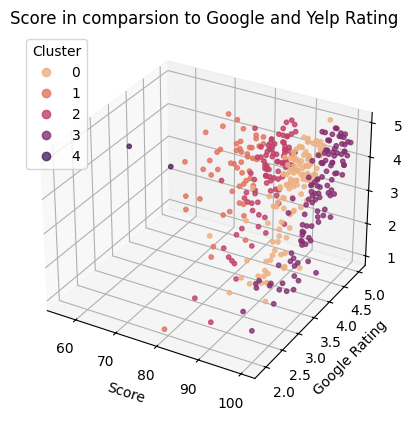

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection ='3d')
#Define axes
x = ratings_df['Score']
y = ratings_df['Google Rating']
z = ratings_df['Yelp Rating']
scatter = ax.scatter(x, y, z, c=ratings_df['Cluster'], cmap='flare', alpha = .80, s=10)

ax.set_xlabel('Score')
ax.set_ylabel('Google Rating')
ax.set_zlabel('Yelp Rating')
ax.set_title('Score in comparsion to Google and Yelp Rating')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='upper left')

Looking at how the data is visualized here, while we can see how the clusters are arranged, another visualization is needed so that people can understand how these clusters can be applied on the Austin city map. In order to do this, we need to utilize Tableau to draw out a map of city and color code each restaurant.

In [ ]:
ratings_df.head()

,Unnamed: 0,Restaurant Name,Zip Code,Inspection Date,Score,Address,Google Rating,Yelp Rating,Cluster
0,13560,Jason's Deli,78748,2022-12-16,96,"9600 S IH AUSTIN, TX 78748",4.4,3.7,3
1,15139,MN - Dollar General #6946,78653,2023-08-25,93,"12750 LAPOYNOR ST MANOR, TX 78653",3.9,1.5,0
2,8695,Headliners,78701,2022-07-18,86,"221 W 6TH ST AUSTIN, TX 78701",4.7,4.7,2
3,787,Kung Fu Tea,78757,NaT,78,"9070 RESEARCH BLVD AUSTIN, TX 78757",4.4,4.3,1
4,6023,LW - Santa Catarina,78734,2023-08-02,81,"1310 S FM 620 RD LAKEWAY, TX 78734",4.5,4.4,1


In [ ]:
#In order to utilize Tableau, we need to turn the labelled clusters into a csv file
ratings_df[['Score', 'Restaurant Name', 'Address', 'Google Rating',
            'Yelp Rating', 'Cluster']].to_csv("Labelled_clusters.csv")

# **Supervising Learning**

Using linear regression "supervised learning" to predict the health inspection according to the input features (Google Rating, Yelp Rating, and zipcode).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# based solely on zip code, google rating, yelp rating columns
features = ratings_df[['Google Rating', 'Yelp Rating']]

X = features
y = ratings_df[['Score']]

# data sets are split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)

# train the model to output health prediction score according to google rating, yelp rating, and zip code
restaurant_new = pd.DataFrame({'Google Rating': [3.9], 'Yelp Rating': [1.5]})
health_prediction = model.predict(restaurant_new)

print(f"Health Inspection Score Prediction: {health_prediction}")

Health Inspection Score Prediction: [[91.08201593]]


80% training data, 20% test data.

**Training**: Our input features are Google Rating, Yelp rating, and zip code. Our output will be the health inspection score. We split the data into 80% training data and then 20% test data, and used linear regression

In [ ]:
import math
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

predict = model.predict(X_test)

mse = mean_squared_error(y_test, predict)

mae = mean_absolute_error(y_test, predict)

print("Mean Squared Error:" ,mse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 57.59323128366448
Mean Absolute Error: 5.964801057392827


**Evaluation**:

*   Mean Squared Error: The value is extremely far from 0, meaning that forecast is not close to the actual value.
*   Mean Absolute Error: On average, the predicted value is off by around 6 for the actual value. This means a value of 60 could actually be 54-66.

In [ ]:
restaurant_new = pd.DataFrame([
    {'Google Rating': 3.9, 'Yelp Rating': 1.5},   #High Google, Low Yelp
    {'Google Rating': 4.7, 'Yelp Rating': 4.5},   #High Google and Yelp
    {'Google Rating': 1, 'Yelp Rating': 1.2},     #Low Google and Yelp
    {'Google Rating': 2.5, 'Yelp Rating': 4.6}])   #Low Google and High Yelp
health_prediction = model.predict(restaurant_new)

print(f"Health Inspection Score Prediction: {health_prediction}")
print("Actual/Envisioned values")
actual = """[90]
[99]
[75]
[85]"""
print(actual)

Health Inspection Score Prediction: [[91.08201593]
 [90.47547242]
 [89.25019616]
 [88.96096032]]
Actual/Envisioned values
[90]
[99]
[75]
[85]


Text(0.5, 1.0, 'Correlation Heatmap')

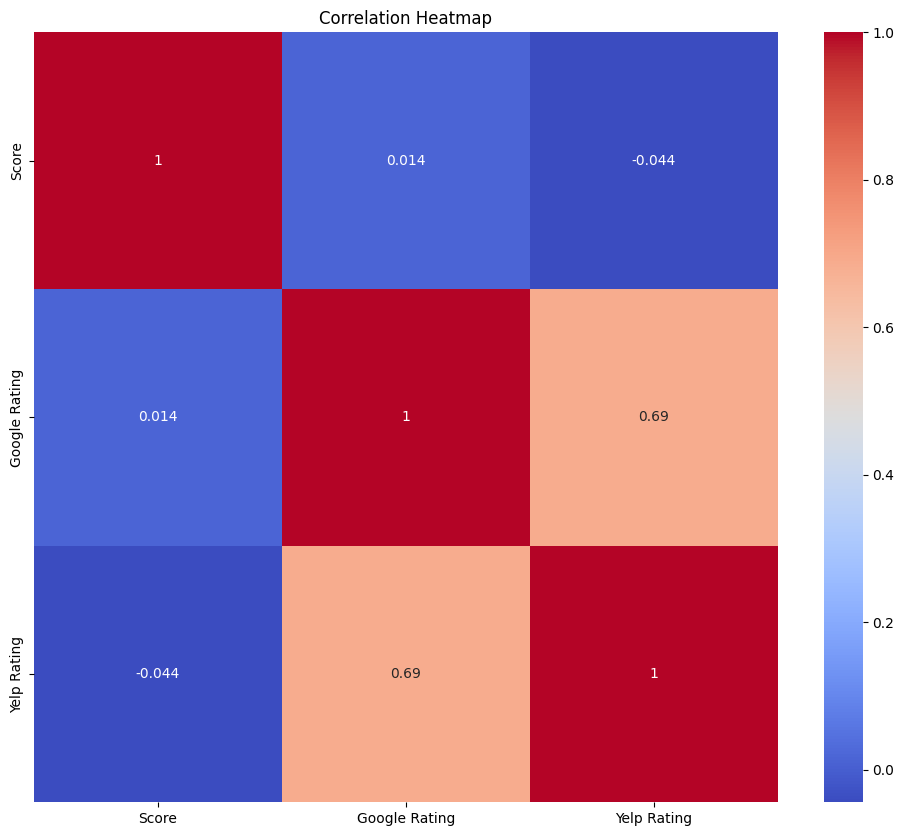

In [ ]:
cols = ['Score', 'Google Rating', 'Yelp Rating']
plt.figure(figsize=(12,10))
corr_matrix = ratings_df[cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")